# Ejercicio 5 - Práctica 4

El set de datos `viajes_tup.xlsx` contiene información sobre el número de viajes mensuales registrados en el Transporte Urbano de Pasajeros (TUP) de la ciudad de Rosario entre los años 2015 y 2021.

1. Realice una tabla que resuma el total de viajes realizados por año y represente gráficamente dicha información. ¿Cuál fue el año en el que se registró la mayor cantidad de viajes en el TUP?

2. Construya un gráfico en el que se represente la evolución del número de viajes registrados en el TUP a lo largo de los meses para los años 2019 y 2020. Comente brevemente lo observado.

## Cargamos el data frame

In [3]:
# Importamos los paquetes necesarios

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

In [6]:
df = pd.read_excel("../datasets/viajes_tup.xlsx")
df.head()

,periodo,validaciones_totales
0,2015-01-01,8325035
1,2015-02-01,8472410
2,2015-03-01,10486899
3,2015-04-01,11865691
4,2015-05-01,11568866


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   periodo               84 non-null     datetime64[us]
 1   validaciones_totales  84 non-null     int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 1.4 KB


## Item 1

Realice una tabla que resuma el total de viajes realizados por año y represente gráficamente dicha información. ¿Cuál fue el año en el que se registró la mayor cantidad de viajes en el TUP?


In [10]:
df.groupby([df['periodo'].dt.year.rename('AÑO')])['validaciones_totales'].sum()

# El año 2017 tiene la mayor cantidad de vaijes.

AÑO
2015    130867042
2016    134931801
2017    135495961
2018    127581349
2019    117025617
2020     38096306
2021     65240461
Name: validaciones_totales, dtype: int64

# Item 2

Construya un gráfico en el que se represente la evolución del número de viajes registrados en el TUP a lo largo de los meses para los años 2019 y 2020. Comente brevemente lo observado.

In [30]:
df.groupby([df['periodo'].dt.year.rename('AÑO')])['validaciones_totales'].sum()

# Nos quedamos con los datos en el rago de fechas (último año)
datos = df[(df['periodo'] < "2021-01-01") & (df['periodo'] >= "2019-01-01")] \
        .groupby([df['periodo'].dt.year.rename('ANIO'), 
                df['periodo'].dt.month.rename('MES')])['validaciones_totales'] \
                .sum()

datos = datos.reset_index(name = "VALIDACIONES")
datos['FECHA'] = datos['ANIO'].astype(str) + '-' + datos['MES'].astype(str)

datos.head()

,ANIO,MES,VALIDACIONES,FECHA
0,2019,1,7588428,2019-1
1,2019,2,7968998,2019-2
2,2019,3,9410231,2019-3
3,2019,4,9930242,2019-4
4,2019,5,10746036,2019-5


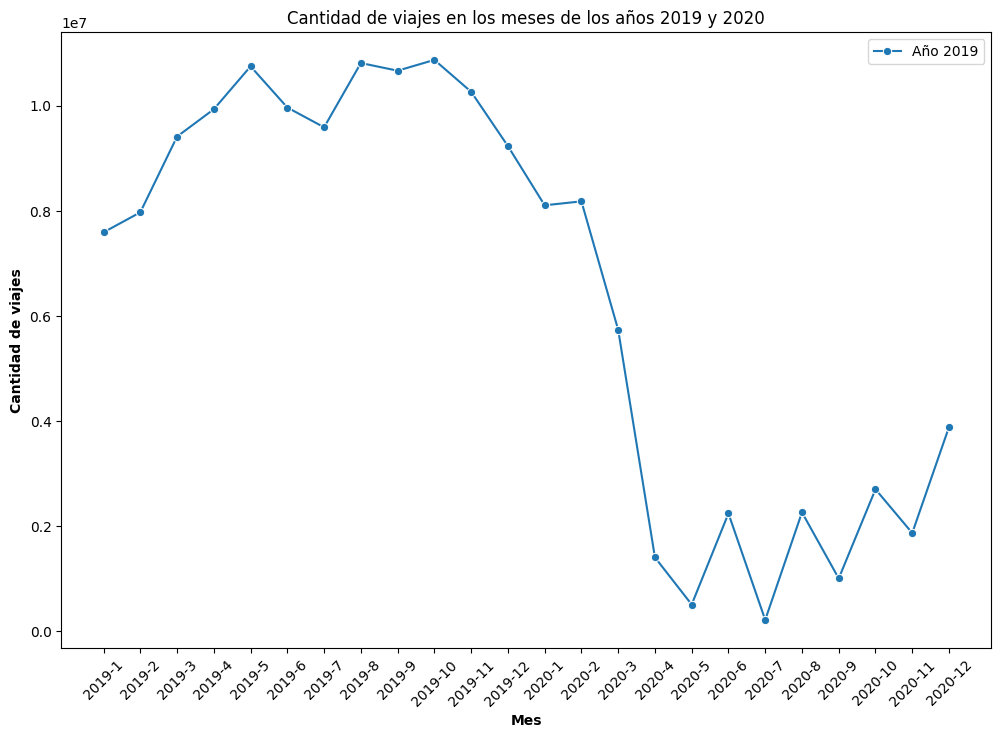

In [35]:
plt.figure(figsize = (12,8))

sns.lineplot(x = 'FECHA', y = 'VALIDACIONES', marker = 'o', data = datos, label='Año 2019')

plt.xlabel('Mes', fontweight = 'bold')
plt.xticks(rotation=45)
plt.ylabel('Cantidad de viajes', fontweight = 'bold')


plt.title('Cantidad de viajes en los meses de los años 2019 y 2020')

plt.show()

Claramente los viajes disminuyeron drásticamente cuando comenzó la pandemia.